In [1]:
import numpy as np
np.random.seed(2)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from PIL import Image, ImageChops, ImageEnhance
import os
import itertools

In [5]:
def convert_to_ela_image(path, quality):
    temp_filename = 'temp_file_name.jpg'
    ela_filename = 'temp_ela.png'
    image = Image.open(path).convert('RGB')
    image.save(temp_filename, 'JPEG', quality = quality)
    temp_image = Image.open(temp_filename)
    ela_image = ImageChops.difference(image, temp_image)
    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
    return ela_image

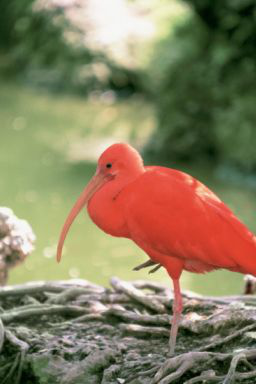

In [ ]:
real_image_path = '/CASIA2/Au/Au_ani_00064.jpg'
Image.open(real_image_path)

In [9]:
image_size = (128, 128)

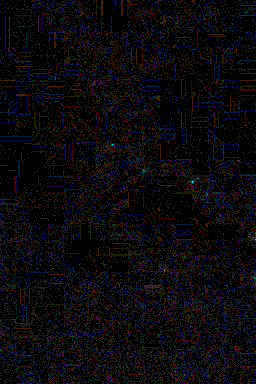

In [11]:
convert_to_ela_image(real_image_path, 90)

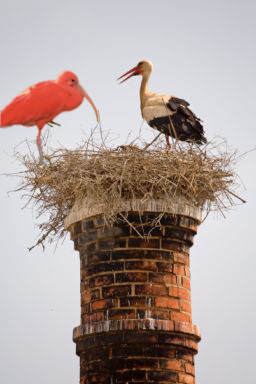

In [ ]:
fake_image_path = '/CASIA2/Tp/Tp_D_CRD_S_B_ani00071_ani00064_00191.tif'
Image.open(fake_image_path)

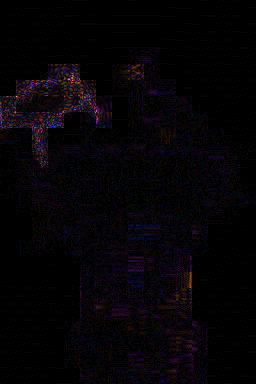

In [15]:
convert_to_ela_image(fake_image_path, 90)

In [17]:
def prepare_image(image_path):
    return np.array(convert_to_ela_image(image_path, 90).resize(image_size)).flatten() / 255.0

In [19]:
X = [] # ELA converted images
Y = [] # 0 for real, 1 for splicing, 2 for copy-move

In [ ]:
path = '/CASIA2/Au'
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('jpg') or filename.endswith('png'):
            full_path = os.path.join(dirname, filename)
            X.append(prepare_image(full_path))
            Y.append(0)  # Real image
            if len(Y) % 500 == 0:
                print(f'Processing {len(Y)} images')

print(len(X), len(Y))

Processing 500 images
Processing 1000 images
Processing 1500 images
Processing 2000 images
Processing 2500 images
Processing 3000 images
Processing 3500 images
Processing 4000 images
Processing 4500 images
Processing 5000 images
Processing 5500 images
Processing 6000 images
Processing 6500 images
Processing 7000 images
7354 7354


In [ ]:
path = '/CASIA2/Tp'
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('jpg') or filename.endswith('png') or filename.endswith('tif'):
            full_path = os.path.join(dirname, filename)
            
            # Determine forgery type based on filename
            if 'Tp_D' in filename:
                forgery_class = 1  # Splicing
            elif 'Tp_S' in filename:
                forgery_class = 2  # Copy-move
            else:
                # If can't determine the type, default to splicing
                forgery_class = 1
                
            X.append(prepare_image(full_path))
            Y.append(forgery_class)
            
            if len(Y) % 500 == 0:
                print(f'Processing {len(Y)} images')

print(len(X), len(Y))

Processing 7500 images
Processing 8000 images
Processing 8500 images
Processing 9000 images
Processing 9500 images
Processing 10000 images
Processing 10500 images
Processing 11000 images
Processing 11500 images
Processing 12000 images
12477 12477


In [25]:
unique, counts = np.unique(Y, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

Class distribution: {0: 7354, 1: 1849, 2: 3274}


In [27]:
from tensorflow.keras.utils import to_categorical
import numpy as np
X = np.array(X)
Y = to_categorical(Y, 3)  
X = X.reshape(-1, 128, 128, 3) 

In [29]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=5)
print(len(X_train), len(Y_train))
print(len(X_val), len(Y_val))

9981 9981
2496 2496


In [31]:
def build_model():
    model = Sequential()
    model.add(Conv2D(filters=32, kernel_size=(5, 5), padding='valid', activation='relu', input_shape=(128, 128, 3)))
    model.add(Conv2D(filters=32, kernel_size=(5, 5), padding='valid', activation='relu'))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    
    # convolutional block for better feature extraction
    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='valid', activation='relu'))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='valid', activation='relu'))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    # 3 output neurons for 3 classes
    model.add(Dense(3, activation='softmax'))
    return model

model = build_model()
model.summary()


D:\New folder\anoconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 58, 58, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929,571 (49.32 MB)

 Trainable params: 12,929,571 (49.32 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
epochs = 30
batch_size = 32
init_lr = 1e-4
optimizer = Adam(learning_rate=init_lr, weight_decay=init_lr/epochs)
# categorical_crossentropy
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [43]:
from tensorflow.keras.callbacks import ModelCheckpoint

#  model checkpoint to save the best model
checkpoint = ModelCheckpoint(
    'best_forgery_classifier1.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [45]:
data_augmentation = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
class_counts = np.sum(Y_train, axis=0)
class_weights = None
if np.std(class_counts) > class_counts.mean() * 0.2:  # Check if imbalanced
    class_weights = {i: class_counts.sum() / (len(class_counts) * count) for i, count in enumerate(class_counts)}
    print("Using class weights:", class_weights)

Using class weights: {0: 0.5667802385008518, 1: 2.218, 2: 1.274224435082344}


In [53]:
hist = model.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, Y_val),
    callbacks=[checkpoint],
    class_weight=class_weights
)

Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6530 - loss: 0.8654
Epoch 1: val_accuracy improved from -inf to 0.66186, saving model to best_forgery_classifier1.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 482s 2s/step - accuracy: 0.6530 - loss: 0.8652 - val_accuracy: 0.6619 - val_loss: 0.6525
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6792 - loss: 0.7489
Epoch 2: val_accuracy did not improve from 0.66186
312/312 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.6791 - loss: 0.7489 - val_accuracy: 0.6611 - val_loss: 0.6662
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7042 - loss: 0.7196
Epoch 3: val_accuracy improved from 0.66186 to 0.70433, saving model to best_forgery_classifier1.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 450s 1s/step - accuracy: 0.7042 - loss: 0.7196 - val_accuracy: 0.7043 - val_loss: 0.6079
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7173 - loss: 0.7063
Epoch 4: val_accuracy improved from 0.70433 to 0.74199, saving model to best_forgery_classifier1.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 453s 1s/step - accuracy: 0.7173 - loss: 0.7063 - val_accuracy: 0.7420 - val_loss: 0.5598
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7256 - loss: 0.6941
Epoch 5: val_accuracy did not improve from 0.74199
312/312 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.7256 - loss: 0.6941 - val_accuracy: 0.6895 - val_loss: 0.6349
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7231 - loss: 0.6936
Epoch 6: val_accuracy did not improve from 0.74199
312/312 ━━━━━━━━━━━━━━━━━━━━ 443s 1s/step - accuracy: 0.7231 - loss: 0.6935 - val_accuracy: 0.7260 - val_loss: 0.5727
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7407 - loss: 0.6473
Epoch 7: val_accuracy improved from 0.74199 to 0.76042, saving model to best_forgery_classifier1.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.7407 - loss: 0.6474 - val_accuracy: 0.7604 - val_loss: 0.5206
Epoch 8/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7606 - loss: 0.6238
Epoch 8: val_accuracy did not improve from 0.76042
312/312 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.7607 - loss: 0.6237 - val_accuracy: 0.7548 - val_loss: 0.5129
Epoch 9/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7787 - loss: 0.5767
Epoch 9: val_accuracy improved from 0.76042 to 0.76562, saving model to best_forgery_classifier1.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.7787 - loss: 0.5768 - val_accuracy: 0.7656 - val_loss: 0.5056
Epoch 10/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7861 - loss: 0.5507
Epoch 10: val_accuracy did not improve from 0.76562
312/312 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.7861 - loss: 0.5507 - val_accuracy: 0.7504 - val_loss: 0.5219
Epoch 11/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7918 - loss: 0.5377
Epoch 11: val_accuracy improved from 0.76562 to 0.77444, saving model to best_forgery_classifier1.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.7918 - loss: 0.5377 - val_accuracy: 0.7744 - val_loss: 0.4991
Epoch 12/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8138 - loss: 0.5083
Epoch 12: val_accuracy improved from 0.77444 to 0.77604, saving model to best_forgery_classifier1.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.8138 - loss: 0.5083 - val_accuracy: 0.7760 - val_loss: 0.4960
Epoch 13/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8213 - loss: 0.4806
Epoch 13: val_accuracy did not improve from 0.77604
312/312 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.8213 - loss: 0.4806 - val_accuracy: 0.7568 - val_loss: 0.5430
Epoch 14/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8241 - loss: 0.4660
Epoch 14: val_accuracy improved from 0.77604 to 0.79728, saving model to best_forgery_classifier1.h5


312/312 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.8241 - loss: 0.4660 - val_accuracy: 0.7973 - val_loss: 0.4919
Epoch 15/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8413 - loss: 0.4229
Epoch 15: val_accuracy did not improve from 0.79728
312/312 ━━━━━━━━━━━━━━━━━━━━ 443s 1s/step - accuracy: 0.8413 - loss: 0.4229 - val_accuracy: 0.7825 - val_loss: 0.5222
Epoch 16/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8499 - loss: 0.3954
Epoch 16: val_accuracy did not improve from 0.79728
312/312 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.8499 - loss: 0.3955 - val_accuracy: 0.7612 - val_loss: 0.5736
Epoch 17/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8576 - loss: 0.3736
Epoch 17: val_accuracy did not improve from 0.79728
312/312 ━━━━━━━━━━━━━━━━━━━━ 443s 1s/step - accuracy: 0.8576 - loss: 0.3736 - val_accuracy: 0.7961 - val_loss: 0.5161
Epoch 18/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8703 - loss: 0.3584
Epoch 18: val_accuracy did n

312/312 ━━━━━━━━━━━━━━━━━━━━ 466s 1s/step - accuracy: 0.8907 - loss: 0.2703 - val_accuracy: 0.8053 - val_loss: 0.6027
Epoch 23/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8977 - loss: 0.2547
Epoch 23: val_accuracy did not improve from 0.80529
312/312 ━━━━━━━━━━━━━━━━━━━━ 450s 1s/step - accuracy: 0.8977 - loss: 0.2548 - val_accuracy: 0.7768 - val_loss: 0.6026
Epoch 24/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8882 - loss: 0.2680
Epoch 24: val_accuracy did not improve from 0.80529
312/312 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.8882 - loss: 0.2680 - val_accuracy: 0.7973 - val_loss: 0.6026
Epoch 25/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9056 - loss: 0.2289
Epoch 25: val_accuracy did not improve from 0.80529
312/312 ━━━━━━━━━━━━━━━━━━━━ 443s 1s/step - accuracy: 0.9056 - loss: 0.2289 - val_accuracy: 0.7893 - val_loss: 0.7049
Epoch 26/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9050 - loss: 0.2299
Epoch 26: val_accuracy did n

In [55]:
from tensorflow.keras.models import load_model
model = load_model('best_forgery_classifier1.h5')

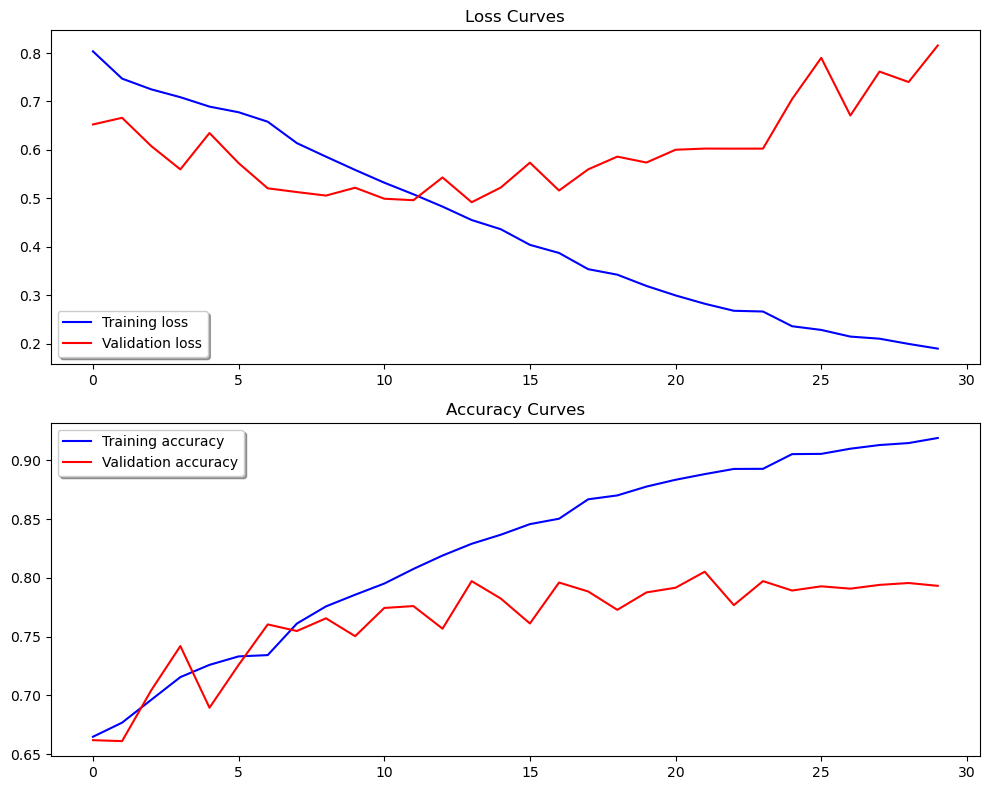

In [57]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(hist.history['loss'], color='b', label="Training loss")
ax[0].plot(hist.history['val_loss'], color='r', label="Validation loss")
ax[0].set_title('Loss Curves')
ax[0].legend(loc='best', shadow=True)

ax[1].plot(hist.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(hist.history['val_accuracy'], color='r', label="Validation accuracy")
ax[1].set_title('Accuracy Curves')
ax[1].legend(loc='best', shadow=True)

plt.tight_layout()
plt.show()

In [59]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 402ms/step


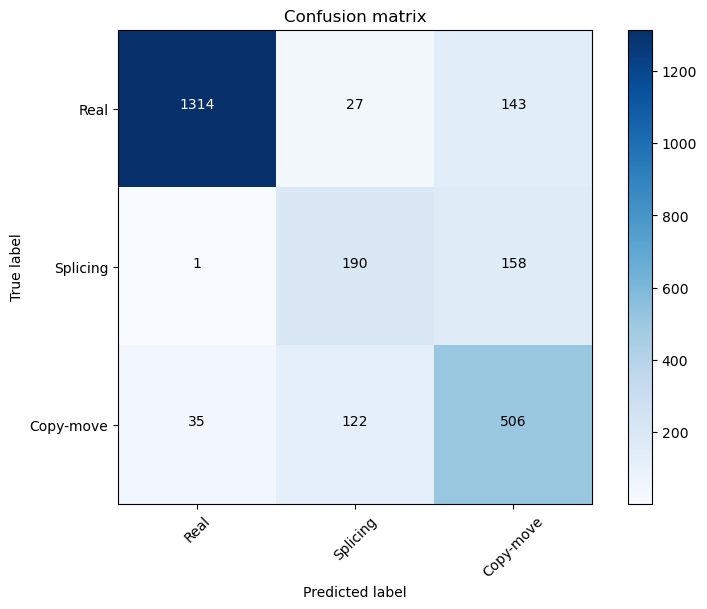

In [61]:
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
plot_confusion_matrix(confusion_mtx, classes=['Real', 'Splicing', 'Copy-move'])

78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 415ms/step
Confusion matrix:
[[1314   27  143]
 [   1  190  158]
 [  35  122  506]]
Classification report:
              precision    recall  f1-score   support

        Real       0.97      0.89      0.93      1484
    Splicing       0.56      0.54      0.55       349
   Copy-move       0.63      0.76      0.69       663

    accuracy                           0.81      2496
   macro avg       0.72      0.73      0.72      2496
weighted avg       0.82      0.81      0.81      2496

Overall accuracy: 80.53%


<Figure size 800x600 with 0 Axes>

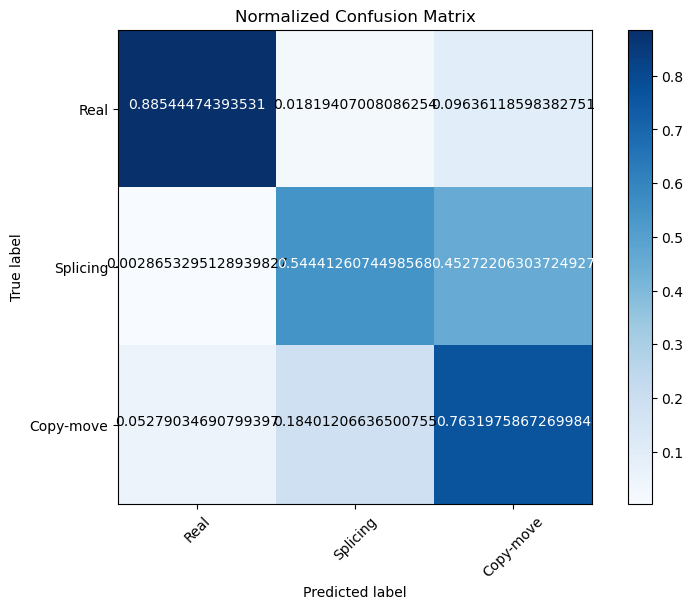

In [63]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Generate predictions on validation set
predictions = model.predict(X_val)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(Y_val, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:")
print(cm)

# Define class names for reporting
target_names = ['Real', 'Splicing', 'Copy-move']
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Calculate overall accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Overall accuracy: {:.2f}%".format(accuracy*100))

# Plot normalized confusion matrix for better visualization of class-wise performance
plt.figure(figsize=(8, 6))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plot_confusion_matrix(cm_normalized, classes=target_names, normalize=True, 
                     title='Normalized Confusion Matrix')

In [65]:
def predict_image_type(image_path):
    # Prepare image
    processed_image = prepare_image(image_path)
    processed_image = processed_image.reshape(1, 128, 128, 3)
    
    # Get prediction
    prediction = model.predict(processed_image)
    pred_class = np.argmax(prediction, axis=1)[0]
    
    # Map to class name
    class_names = ['Real', 'Splicing', 'Copy-move']
    result = class_names[pred_class]
    
    # Get confidence score
    confidence = prediction[0][pred_class] * 100
    
    return result, confidence


In [ ]:
test_image_path = 'CASIA2/Au/Au_ani_00002.jpg'
result, confidence = predict_image_type(test_image_path)
print(f"Image is predicted to be: {result} (Confidence: {confidence:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
Image is predicted to be: Real (Confidence: 99.90%)


In [ ]:
test_image_path = 'CASIA2/Tp/Tp_D_CNN_S_N_ani00053_ani00051_11148.jpg'
result, confidence = predict_image_type(test_image_path)
print(f"Image is predicted to be: {result} (Confidence: {confidence:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Image is predicted to be: Splicing (Confidence: 90.61%)


In [ ]:
test_image_path = 'CASIA2/Tp/Tp_S_CNN_S_N_nat00091_nat00091_11098.jpg'
result, confidence = predict_image_type(test_image_path)
print(f"Image is predicted to be: {result} (Confidence: {confidence:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Image is predicted to be: Copy-move (Confidence: 95.92%)


In [61]:
model.save('multi_class_forgery_detector1.h5')
print("Model saved as 'multi_class_forgery_detector1.h5'")

Model saved as 'multi_class_forgery_detector.h5'
